In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / 'data'
print('repo root:', REPO_ROOT)
print('data dir :', DATA_DIR)

repo root: /Users/ohdoyoel/work/side/cs377/project
data dir : /Users/ohdoyoel/work/side/cs377/project/data


In [2]:
df_random = pd.read_parquet(DATA_DIR / 'rollouts_random.parquet')
df_geom   = pd.read_parquet(DATA_DIR / 'rollouts_geometric.parquet')
print('random :', len(df_random), 'episodes')
print('geom   :', len(df_geom),   'episodes')
df_random.head()

random : 10000 episodes
geom   : 10000 episodes


,ep,theta,power,a,b,score,fouled,cushion_hits,duration,n_events,n_cue_hits_red
0,0,4.002148,0.269787,0.201329,0.020983,0,False,1,4.073976,2,1
1,1,5.109928,0.912756,-0.100062,-0.772414,0,False,3,4.847641,3,0
2,2,3.415697,0.935072,0.903112,0.015541,0,False,2,6.034352,3,1
3,3,5.387230,0.033586,0.384660,0.762688,0,False,0,0.700000,0,0
4,4,5.423513,0.541461,-0.484127,0.255603,0,False,3,3.885347,3,0


In [3]:
def _summary(df: pd.DataFrame, label: str) -> dict:
    return {
        'policy': label,
        'n_episodes': len(df),
        'score_rate': df['score'].mean(),
        'foul_rate' : df['fouled'].mean(),
        'mean_cushion_hits': df['cushion_hits'].mean(),
        'mean_duration_s' : df['duration'].mean(),
    }

summary = pd.DataFrame([_summary(df_random, 'random'), _summary(df_geom, 'geometric')])
summary

,policy,n_episodes,score_rate,foul_rate,mean_cushion_hits,mean_duration_s
0,random,10000,0.0088,0.1556,1.9578,3.684280
1,geometric,10000,0.0000,0.0000,0.0000,4.396467


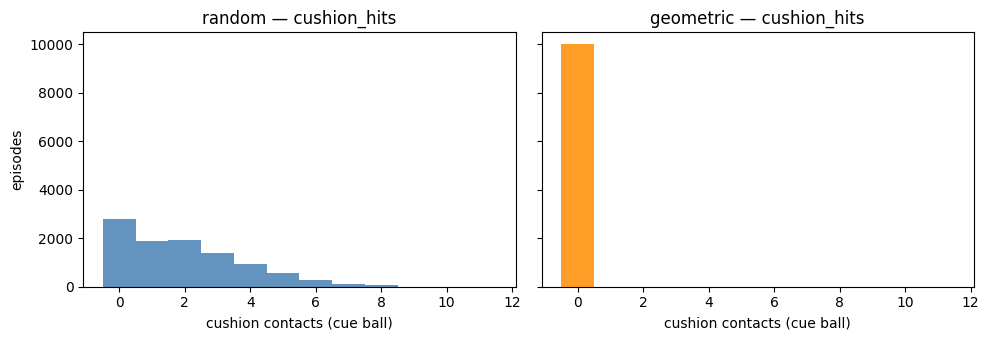

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
bins = np.arange(0, max(df_random['cushion_hits'].max(), df_geom['cushion_hits'].max()) + 2) - 0.5
axes[0].hist(df_random['cushion_hits'], bins=bins, color='steelblue', alpha=0.85)
axes[0].set_title('random — cushion_hits')
axes[0].set_xlabel('cushion contacts (cue ball)')
axes[0].set_ylabel('episodes')
axes[1].hist(df_geom['cushion_hits'], bins=bins, color='darkorange', alpha=0.85)
axes[1].set_title('geometric — cushion_hits')
axes[1].set_xlabel('cushion contacts (cue ball)')
fig.tight_layout()
plt.show()

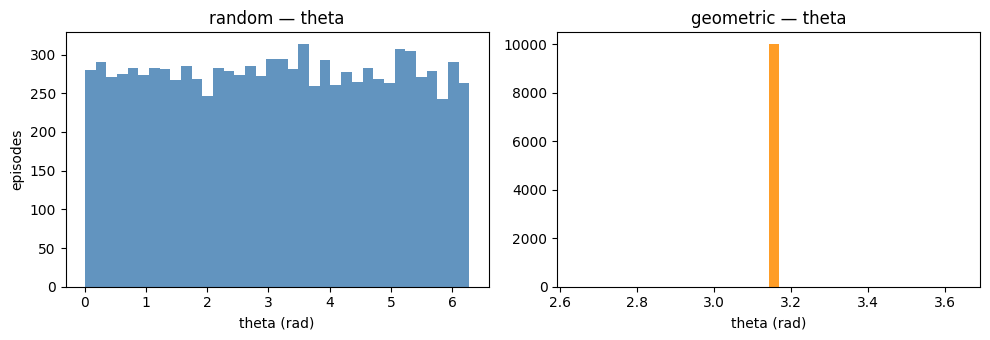

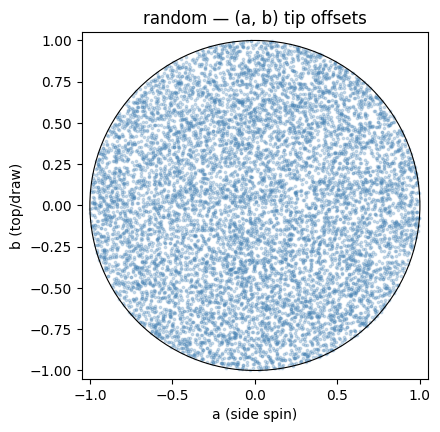

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df_random['theta'], bins=36, color='steelblue', alpha=0.85)
axes[0].set_title('random — theta')
axes[0].set_xlabel('theta (rad)')
axes[0].set_ylabel('episodes')
axes[1].hist(df_geom['theta'], bins=36, color='darkorange', alpha=0.85)
axes[1].set_title('geometric — theta')
axes[1].set_xlabel('theta (rad)')
fig.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(df_random['a'], df_random['b'], s=3, alpha=0.25, color='steelblue')
ax.set_aspect('equal')
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
circ = plt.Circle((0, 0), 1.0, fill=False, color='black', lw=0.8)
ax.add_patch(circ)
ax.set_title('random — (a, b) tip offsets')
ax.set_xlabel('a (side spin)')
ax.set_ylabel('b (top/draw)')
plt.show()

In [6]:
top_cushion = (
    df_random.sort_values('cushion_hits', ascending=False)
             .head(10)
             .reset_index(drop=True)
)
top_cushion[['ep', 'cushion_hits', 'score', 'fouled', 'duration', 'theta', 'power']]

,ep,cushion_hits,score,fouled,duration,theta,power
0,4479,11,0,False,6.089901,3.878014,0.970797
1,5661,11,0,False,5.856485,2.417315,0.926510
2,2759,10,0,False,4.890593,0.549906,0.968830
3,7482,10,0,False,5.405564,0.958514,0.966773
4,1478,9,0,False,6.176173,2.454665,0.963935
5,8011,9,0,False,6.027168,2.450910,0.824472
6,3302,9,0,True,5.744578,4.444584,0.962432
7,3619,9,0,False,4.770229,1.353372,0.951498
8,505,9,0,False,6.550020,2.568617,0.914587
9,5363,9,0,False,4.994128,5.932332,0.819778


### Verdict
Computed below from the two parquet files.

In [7]:
rs = float(df_random['score'].mean())
gs = float(df_geom['score'].mean())
improvement = (gs / rs) if rs > 0 else float('inf')
print(f'random_score={100*rs:.2f}% geometric_score={100*gs:.2f}% (improvement={improvement:.2f}x)')

random_score=0.88% geometric_score=0.00% (improvement=0.00x)
